# Data Preparation and Loading Libraries

This section prepares the data for all subsequent analyses (Questions 1-5)

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

# Global constants
START_DATE = "2015-01-01"
END_DATE = "2024-12-31"
TRADING_DAYS = 252
RF_ANNUAL = 0.02

DATA_PATH = "../SPX_database_2010.xlsx"
df = pd.read_excel(DATA_PATH)
df_total_ret = pd.read_excel(DATA_PATH, sheet_name="total_ret")
df_price = pd.read_excel(DATA_PATH, sheet_name="prices")
df_mktcap = pd.read_excel(DATA_PATH, sheet_name="mkt_cap")


In [2]:
import matplotlib.pyplot as plt

# Project 1
# Part A: Data Setup and Portfolio Construction (Preliminary Analysis)

In [3]:
# --- Rule-based universe selection (no hand-picking, no look-ahead) ---
# 1) Restrict all three sheets to the study window.
# 2) Keep only tickers with a complete non-NaN return history over the window
#    (this is a pragmatic filter, acknowledged as a survivorship-lite choice).
# 3) Rank those tickers by market cap as of the FIRST available date in the window
#    and take the top 30.

for _df in (df_total_ret, df_price, df_mktcap):
    _df["Dates"] = pd.to_datetime(_df["Dates"])

mask_ret = (df_total_ret["Dates"] >= START_DATE) & (df_total_ret["Dates"] <= END_DATE)
df_ret_window = df_total_ret.loc[mask_ret].set_index("Dates")

mask_cap = (df_mktcap["Dates"] >= START_DATE) & (df_mktcap["Dates"] <= END_DATE)
df_cap_window = df_mktcap.loc[mask_cap].set_index("Dates")

# Tickers with full return history over the window
valid_tickers = df_ret_window.columns[df_ret_window.notna().all()].tolist()

# Market cap on the first date in the window (known at t=START_DATE, no look-ahead)
first_date = df_cap_window.index.min()
caps_at_start = df_cap_window.loc[first_date, valid_tickers].dropna()

# Top 30 by initial market cap
N_STOCKS = 30
selected_companies = caps_at_start.sort_values(ascending=False).head(N_STOCKS).index.to_numpy()

print(f"Window: {START_DATE} to {END_DATE}")
print(f"Tickers with full history: {len(valid_tickers)}")
print(f"Selected top {N_STOCKS} by market cap on {first_date.date()}:")
print(selected_companies)


Window: 2015-01-01 to 2024-12-31
Tickers with full history: 866
Selected top 30 by market cap on 2015-01-01:
['AAPL UW Equity.1' 'AAPL UW Equity' 'XOM UN Equity' 'XOM UN Equity.1'
 'MSFT UW Equity' 'MSFT UW Equity.1' 'BRK/B UN Equity' 'BRK/B UN Equity.1'
 'GOOGL UW Equity.1' 'GOOGL UW Equity' 'WFC UN Equity.1' 'WFC UN Equity'
 'WMT UN Equity.1' 'WMT UN Equity' 'GE UN Equity.1' 'GE UN Equity'
 'PG UN Equity' 'PG UN Equity.1' 'JPM UN Equity.1' 'JPM UN Equity'
 'META UW Equity.1' 'META UW Equity' 'CVX UN Equity' 'CVX UN Equity.1'
 'ORCL UN Equity.1' 'ORCL UN Equity' 'PFE UN Equity' 'PFE UN Equity.1'
 'VZ UN Equity' 'VZ UN Equity.1']


# Collect daily returns for selected companies and EW & VW portfolios


In [4]:
# --- Prices for selected universe, restricted to the study window ---
df_prices_selected = df_price[["Dates"] + list(selected_companies)]
mask = (df_prices_selected["Dates"] >= START_DATE) & (df_prices_selected["Dates"] <= END_DATE)
df_prices_filtered = df_prices_selected.loc[mask].set_index("Dates")

# --- Daily LOG and SIMPLE returns ---
df_log_returns = np.log(df_prices_filtered / df_prices_filtered.shift(1)).dropna()
df_simple_returns = df_prices_filtered.pct_change().dropna()

# df_returns is the canonical daily log-return DataFrame used downstream
df_returns = df_log_returns.copy()

# EW portfolio (preliminary, unrebalanced) — built from SIMPLE returns then logged
ew_simple_prelim = df_simple_returns.mean(axis=1)
df_returns["Equal_Weighted_Portfolio"] = np.log1p(ew_simple_prelim)

print(df_returns.head())


            AAPL UW Equity.1  AAPL UW Equity  XOM UN Equity  XOM UN Equity.1  \
Dates                                                                          
2015-01-02         -0.009558       -0.009558       0.004102         0.004102   
2015-01-05         -0.028576       -0.028576      -0.027743        -0.027743   
2015-01-06          0.000094        0.000094      -0.005330        -0.005330   
2015-01-07          0.013925        0.013925       0.010082         0.010082   
2015-01-08          0.037703        0.037703       0.016508         0.016508   

            MSFT UW Equity  MSFT UW Equity.1  BRK/B UN Equity  \
Dates                                                           
2015-01-02        0.006652          0.006652        -0.006548   
2015-01-05       -0.009346         -0.009346        -0.014654   
2015-01-06       -0.014678         -0.014678        -0.001089   
2015-01-07        0.012625          0.012625         0.013797   
2015-01-08        0.028994          0.028994     

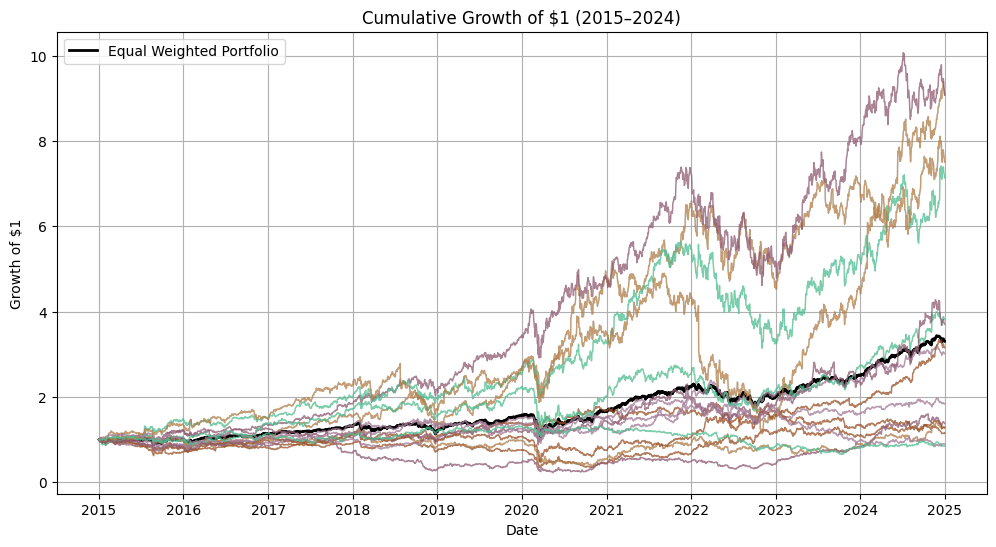

In [5]:
df_cum_returns = np.exp(df_returns.cumsum())

# --- Step 6: Plot cumulative growth of $1 ---
plt.figure(figsize=(12,6))
plt.plot(df_cum_returns.index, df_cum_returns["Equal_Weighted_Portfolio"], label="Equal Weighted Portfolio", linewidth=2, color="black")

# Optional: plot individual companies (light lines)
for col in selected_companies:
    plt.plot(df_cum_returns.index, df_cum_returns[col], alpha=0.5, linewidth=1)

plt.title("Cumulative Growth of $1 (2015–2024)")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

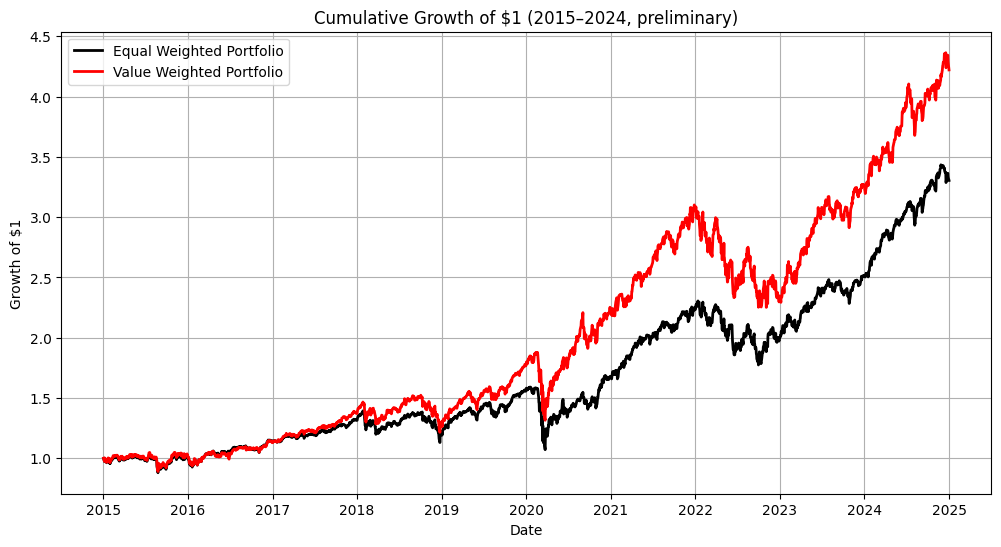

In [6]:
# --- Market cap frame aligned to our return index ---
df_mktcap_selected = df_mktcap[["Dates"] + list(selected_companies)]
mask = (df_mktcap_selected["Dates"] >= START_DATE) & (df_mktcap_selected["Dates"] <= END_DATE)
df_mktcap_filtered = df_mktcap_selected.loc[mask].set_index("Dates")
df_mktcap_filtered = df_mktcap_filtered.reindex(df_returns.index).ffill()

# --- Preliminary VW portfolio (daily re-weight, no calendar rebalance yet) ---
# Correct aggregation: weight SIMPLE returns, not log returns.
weights_daily = df_mktcap_filtered.div(df_mktcap_filtered.sum(axis=1), axis=0).shift(1)
vw_simple_prelim = (df_simple_returns[selected_companies] * weights_daily).sum(axis=1)
df_returns["Value_Weighted_Portfolio"] = np.log1p(vw_simple_prelim)

# --- Cumulative growth of $1 (EW vs VW, preliminary) ---
df_cum_returns = np.exp(df_returns[["Equal_Weighted_Portfolio",
                                    "Value_Weighted_Portfolio"]].cumsum())

plt.figure(figsize=(12, 6))
plt.plot(df_cum_returns.index, df_cum_returns["Equal_Weighted_Portfolio"],
         label="Equal Weighted Portfolio", linewidth=2, color="black")
plt.plot(df_cum_returns.index, df_cum_returns["Value_Weighted_Portfolio"],
         label="Value Weighted Portfolio", linewidth=2, color="red")
plt.title(f"Cumulative Growth of $1 ({START_DATE[:4]}\u2013{END_DATE[:4]}, preliminary)")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()


# Rebalance

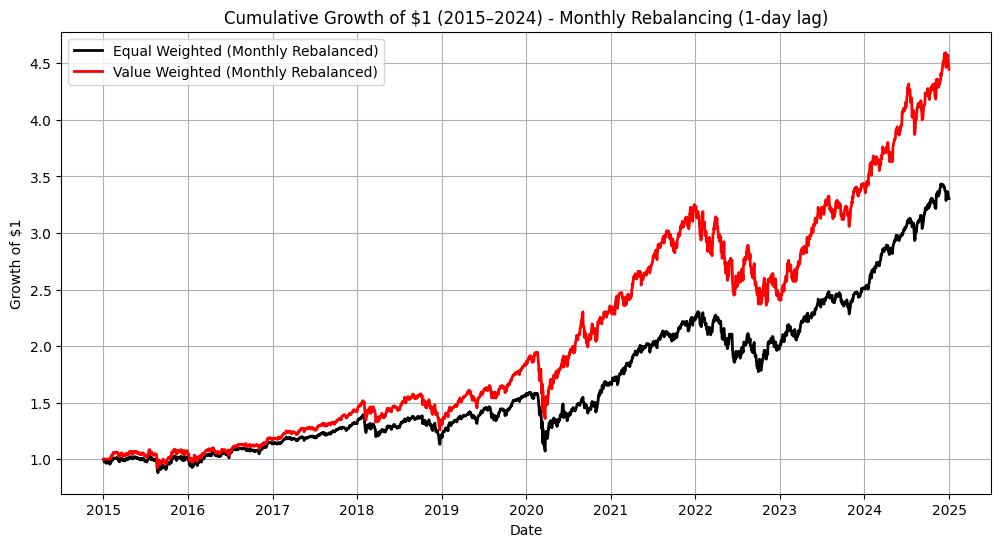

In [7]:
selected = list(selected_companies)  # shorter alias


def first_trading_days(idx, freq):
    """Return the first trading day of each calendar period (freq in {'MS','6MS'})."""
    s = pd.Series(idx, index=idx)
    return pd.DatetimeIndex(s.resample(freq).first().dropna().values)


# Rebalance dates (first trading day of each month / every 6 months)
first_days_1m = first_trading_days(df_returns.index, "MS")
first_days_6m = first_trading_days(df_returns.index, "6MS")

# --- Step 1: daily cap weights, 1-day lag so we never use future info ---
caps_lag = df_mktcap_filtered.loc[df_returns.index, selected].shift(1)

# VW target weights: cap weights on each rebalance date, held constant (no drift rebalance)
vw_monthly_targets = caps_lag.reindex(first_days_1m, method="ffill")
vw_monthly_targets = vw_monthly_targets.div(vw_monthly_targets.sum(axis=1), axis=0)
vw_monthly_weights = vw_monthly_targets.reindex(df_returns.index, method="ffill")

# EW target weights
n = len(selected)
ew_monthly_targets = pd.DataFrame(1.0 / n, index=first_days_1m, columns=selected)
ew_monthly_weights = ew_monthly_targets.reindex(df_returns.index, method="ffill")

# --- Sanity ---
assert np.allclose(vw_monthly_weights.dropna().sum(axis=1), 1.0), "VW weights must sum to 1"
assert np.allclose(ew_monthly_weights.dropna().sum(axis=1), 1.0), "EW weights must sum to 1"

# --- Step 2: portfolio returns from SIMPLE returns ---
simple = df_simple_returns[selected]
vw_port_simple = (simple * vw_monthly_weights).sum(axis=1)
ew_port_simple = (simple * ew_monthly_weights).sum(axis=1)

df_returns["VW_Rebalanced"] = np.log1p(vw_port_simple)
df_returns["EW_Rebalanced"] = np.log1p(ew_port_simple)

# --- Step 3: cumulative growth of $1 ---
df_cum = np.exp(df_returns[["EW_Rebalanced", "VW_Rebalanced"]].cumsum())

plt.figure(figsize=(12, 6))
plt.plot(df_cum.index, df_cum["EW_Rebalanced"],
         label="Equal Weighted (Monthly Rebalanced)", color="black", linewidth=2)
plt.plot(df_cum.index, df_cum["VW_Rebalanced"],
         label="Value Weighted (Monthly Rebalanced)", color="red", linewidth=2)
plt.title(f"Cumulative Growth of $1 ({START_DATE[:4]}\u2013{END_DATE[:4]}) - Monthly Rebalancing (1-day lag)")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()


# Portfolio turnover

In [8]:
# Monthly and semi-annual rebalance dates already built in the previous cell
# via first_trading_days(df_returns.index, "MS"/"6MS").
print("1M rebalance dates:", len(first_days_1m))
print("6M rebalance dates:", len(first_days_6m))


1M rebalance dates: 120
6M rebalance dates: 20


In [9]:
# caps_lag was built in the rebalance cell (1-day lag, aligned to df_returns.index).


def vw_targets_on(dates_index):
    """Value-weight targets on rebalance dates, using ffill (never future-looking)."""
    c = caps_lag.reindex(dates_index, method="ffill")
    return c.div(c.sum(axis=1), axis=0)


# 1M targets were built in the rebalance cell; rebuild 6M targets here for turnover.
vw_6m_targets = vw_targets_on(first_days_6m)
ew_6m_targets = pd.DataFrame(1.0 / n, index=first_days_6m, columns=selected)

# Daily paths (forward-filled between rebalances)
vw_monthly_weights_path = vw_monthly_targets.reindex(df_returns.index, method="ffill")
vw_6m_weights_path = vw_6m_targets.reindex(df_returns.index, method="ffill")


In [10]:
def compute_turnover_with_drift(returns, targets):
    """
    returns: daily simple returns (DataFrame, index daily)
    targets: target weights ONLY at rebalance dates (DataFrame)
             Each row must correspond to the first trading day of a new period,
             defined with t-1 (lagged) information.
    """
    turnovers = {}
    rebalance_dates = targets.index

    for i in range(1, len(rebalance_dates)):
        start = rebalance_dates[i-1]
        end   = rebalance_dates[i]

        # weights right after rebalancing at 'start'
        w0 = targets.loc[start].values

        # apply drift over (start, end] using simple returns
        rets = returns.loc[start:end]
        w = w0.copy()
        for _, r in rets.iloc[1:].iterrows():
            w = w * (1 + r.values)
            w = w / w.sum()

        # target for 'end' (built from t-1 info for 'end')
        w_star = targets.loc[end].values

        turnovers[end] = 0.5 * np.abs(w_star - w).sum()

    return pd.Series(turnovers)


In [11]:
# Turnover computed with drift, using simple returns
ew_turnover_1m = compute_turnover_with_drift(df_simple_returns[selected], ew_monthly_targets)
vw_turnover_1m = compute_turnover_with_drift(df_simple_returns[selected], vw_monthly_targets)

print("Average EW turnover (1M):", ew_turnover_1m.mean())
print("Average VW turnover (1M):", vw_turnover_1m.mean())

ew_turnover_6m = compute_turnover_with_drift(df_simple_returns[selected], ew_6m_targets)
vw_turnover_6m = compute_turnover_with_drift(df_simple_returns[selected], vw_6m_targets)

print("Average EW turnover (6M):", ew_turnover_6m.mean())
print("Average VW turnover (6M):", vw_turnover_6m.mean())


Average EW turnover (1M): 0.02157563078412484
Average VW turnover (1M): 0.006195795909539647
Average EW turnover (6M): 0.06224558531153557
Average VW turnover (6M): 0.006799842346172208


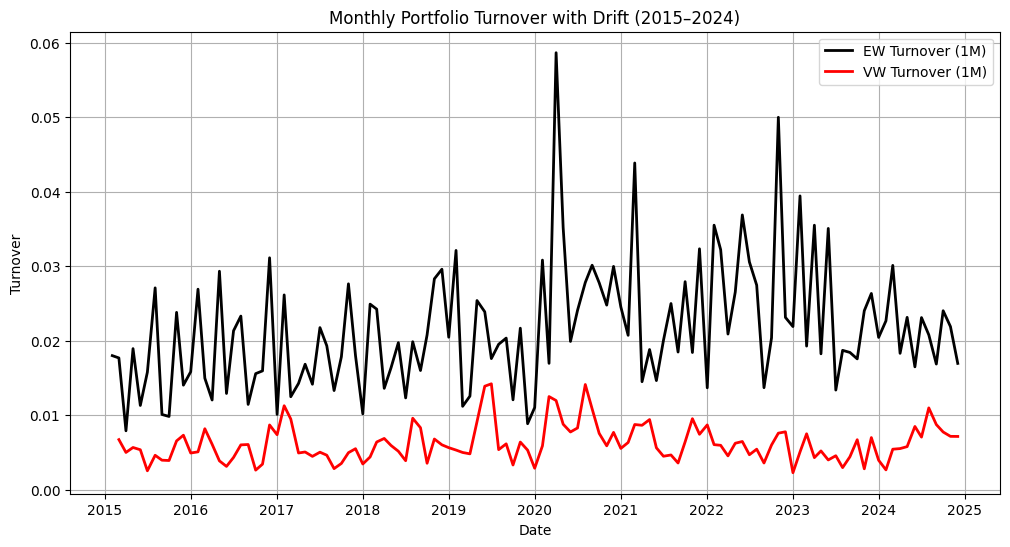

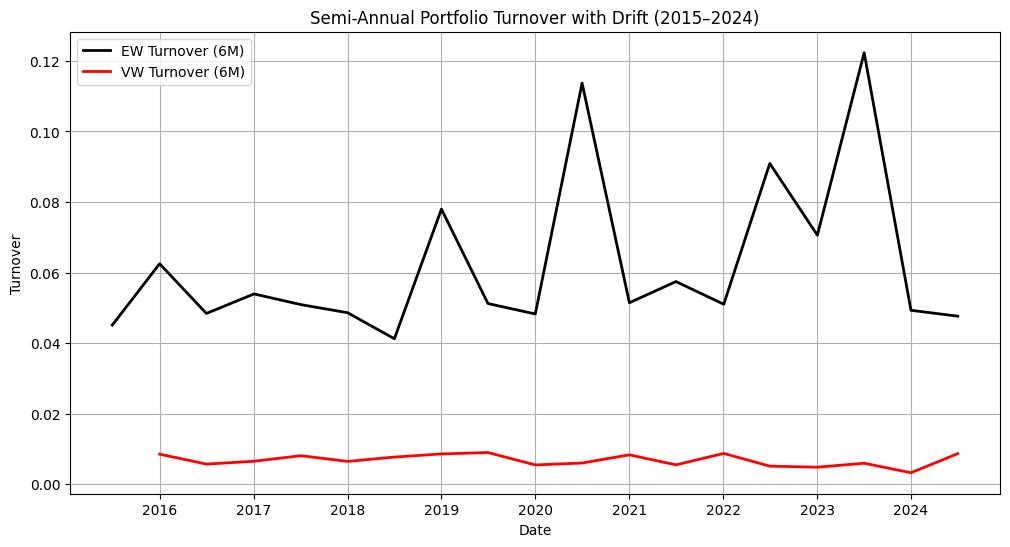

In [12]:
plt.figure(figsize=(12,6))
plt.plot(ew_turnover_1m.index, ew_turnover_1m, label="EW Turnover (1M)", color="black", linewidth=2)
plt.plot(vw_turnover_1m.index, vw_turnover_1m, label="VW Turnover (1M)", color="red", linewidth=2)

plt.title("Monthly Portfolio Turnover with Drift (2015–2024)")
plt.xlabel("Date")
plt.ylabel("Turnover")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))
plt.plot(ew_turnover_6m.index, ew_turnover_6m, label="EW Turnover (6M)", color="black", linewidth=2)
plt.plot(vw_turnover_6m.index, vw_turnover_6m, label="VW Turnover (6M)", color="red", linewidth=2)

plt.title("Semi-Annual Portfolio Turnover with Drift (2015–2024)")
plt.xlabel("Date")
plt.ylabel("Turnover")
plt.legend()
plt.grid(True)
plt.show()

# Calculate daily return from each portfolio

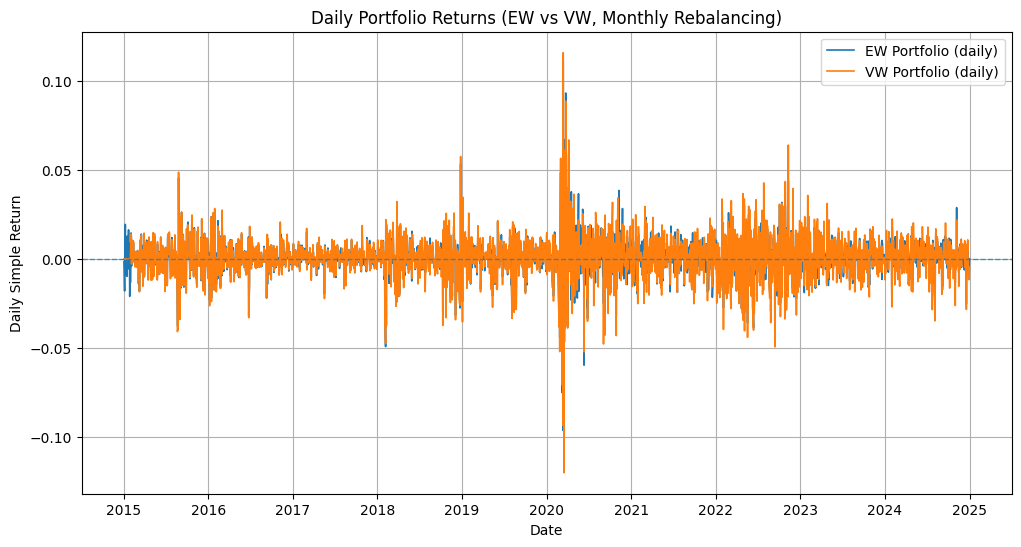

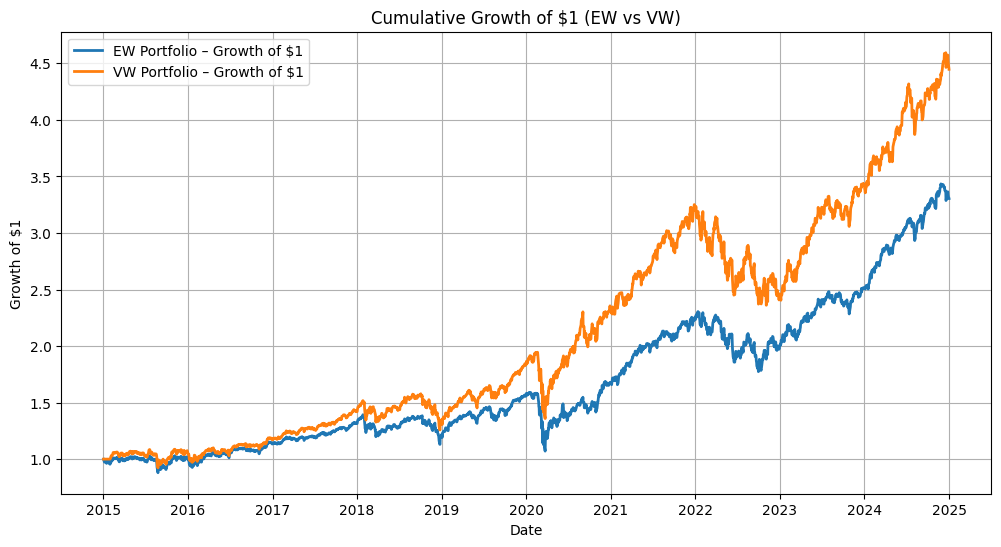

In [13]:
# --- Final daily portfolio returns (monthly rebalanced, simple → log) ---
# Reuses weights built in the rebalance cell. No look-ahead: targets use caps_lag.
simple = df_simple_returns[selected]

ew_port_simple = (simple * ew_monthly_weights).sum(axis=1)
vw_port_simple = (simple * vw_monthly_weights).sum(axis=1)

df_returns["EW_Portfolio"] = ew_port_simple
df_returns["VW_Portfolio"] = vw_port_simple
df_returns["EW_Portfolio_Log"] = np.log1p(ew_port_simple)
df_returns["VW_Portfolio_Log"] = np.log1p(vw_port_simple)

# Semi-annual variants for comparison
ew_6m_weights_path = ew_6m_targets.reindex(df_returns.index, method="ffill")
ew6_port_simple = (simple * ew_6m_weights_path).sum(axis=1)
vw6_port_simple = (simple * vw_6m_weights_path).sum(axis=1)
df_returns["EW6_Portfolio"] = ew6_port_simple
df_returns["VW6_Portfolio"] = vw6_port_simple
df_returns["EW6_Portfolio_Log"] = np.log1p(ew6_port_simple)
df_returns["VW6_Portfolio_Log"] = np.log1p(vw6_port_simple)

# Sanity: every row of weights should sum to 1 where defined
assert np.allclose(ew_monthly_weights.dropna().sum(axis=1), 1.0)
assert np.allclose(vw_monthly_weights.dropna().sum(axis=1), 1.0)

# --- Visualizations ---
plt.figure(figsize=(12, 6))
plt.plot(df_returns.index, df_returns["EW_Portfolio"], label="EW Portfolio (daily)", linewidth=1.2)
plt.plot(df_returns.index, df_returns["VW_Portfolio"], label="VW Portfolio (daily)", linewidth=1.2)
plt.axhline(0.0, linewidth=1, linestyle="--", alpha=0.7)
plt.title("Daily Portfolio Returns (EW vs VW, Monthly Rebalancing)")
plt.xlabel("Date")
plt.ylabel("Daily Simple Return")
plt.legend()
plt.grid(True)
plt.show()

# Growth of $1 (from log returns for numerical stability)
growth_ew = np.exp(df_returns["EW_Portfolio_Log"].cumsum())
growth_vw = np.exp(df_returns["VW_Portfolio_Log"].cumsum())

plt.figure(figsize=(12, 6))
plt.plot(growth_ew.index, growth_ew, label="EW Portfolio \u2013 Growth of $1", linewidth=2)
plt.plot(growth_vw.index, growth_vw, label="VW Portfolio \u2013 Growth of $1", linewidth=2)
plt.title("Cumulative Growth of $1 (EW vs VW)")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()


# Calculation part

In [14]:
import yfinance as yf

# --- S&P 500 benchmark (log returns, tz-naive, aligned to our trading calendar) ---
spx = yf.download(
    "^GSPC", start=START_DATE, end=END_DATE, progress=False, auto_adjust=True
)
price_col = "Adj Close" if "Adj Close" in spx.columns else "Close"
sp500_prices = spx[price_col]
if isinstance(sp500_prices, pd.DataFrame):
    sp500_prices = sp500_prices.iloc[:, 0]
sp500_prices.index = pd.to_datetime(sp500_prices.index).tz_localize(None)
sp500_log = np.log(sp500_prices / sp500_prices.shift(1)).dropna()
sp500_log.name = "SP500_Log"


def portfolio_stats(port_log_returns, benchmark_log_returns=None, rf=RF_ANNUAL):
    """
    Annualized return uses geometric compounding: exp(mean_log * 252) - 1.
    Vol and Sharpe use log-return std as a close approximation.
    """
    port = pd.Series(port_log_returns).dropna()

    if benchmark_log_returns is not None:
        benchmark = pd.Series(benchmark_log_returns).dropna()
        common = port.index.intersection(benchmark.index)
        port = port.loc[common]
        benchmark = benchmark.loc[common]
    else:
        benchmark = None

    ann_return = float(np.exp(port.mean() * TRADING_DAYS) - 1)
    ann_vol = float(port.std() * np.sqrt(TRADING_DAYS))
    sharpe = (ann_return - rf) / ann_vol if ann_vol != 0 else np.nan

    results = {
        "Annualized Return": ann_return,
        "Annualized Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
    }

    if benchmark is not None:
        active = port - benchmark
        ann_active_return = float(active.mean() * TRADING_DAYS)
        ann_tracking_error = float(active.std() * np.sqrt(TRADING_DAYS))
        results["Information Ratio"] = (
            ann_active_return / ann_tracking_error if ann_tracking_error != 0 else np.nan
        )

    return results


ew_stats = portfolio_stats(df_returns["EW_Portfolio_Log"], benchmark_log_returns=sp500_log)
vw_stats = portfolio_stats(df_returns["VW_Portfolio_Log"], benchmark_log_returns=sp500_log)

print("Equal-Weighted Portfolio Stats:")
for k, v in ew_stats.items():
    print(f"  {k}: {v:.4f}")

print("\nValue-Weighted Portfolio Stats:")
for k, v in vw_stats.items():
    print(f"  {k}: {v:.4f}")


Equal-Weighted Portfolio Stats:
  Annualized Return: 0.1274
  Annualized Volatility: 0.1758
  Sharpe Ratio: 0.6110
  Information Ratio: 0.2510

Value-Weighted Portfolio Stats:
  Annualized Return: 0.1619
  Annualized Volatility: 0.1964
  Sharpe Ratio: 0.7225
  Information Ratio: 0.6821



Portfolio Performance Summary (2015–2024):


,Annualized Return,Annualized Volatility,Sharpe Ratio,Information Ratio vs SPX
EW,12.74%,17.58%,0.61,0.25
VW,16.19%,19.64%,0.72,0.68
S&P 500,11.15%,17.89%,0.62,nan


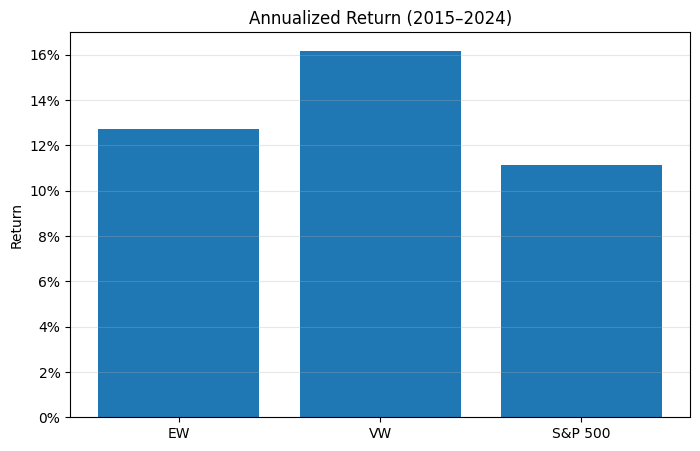

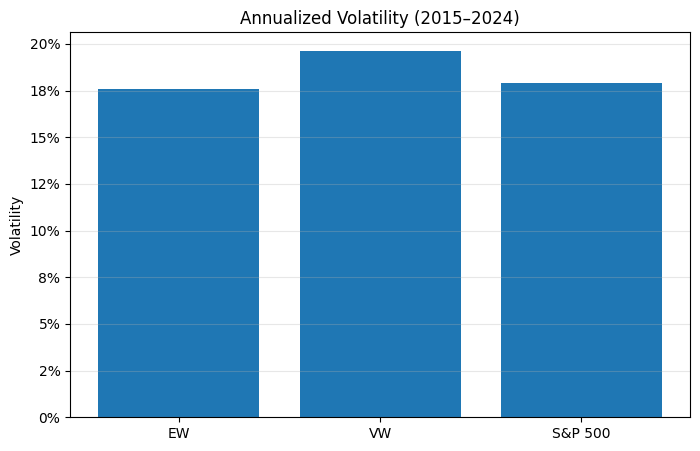

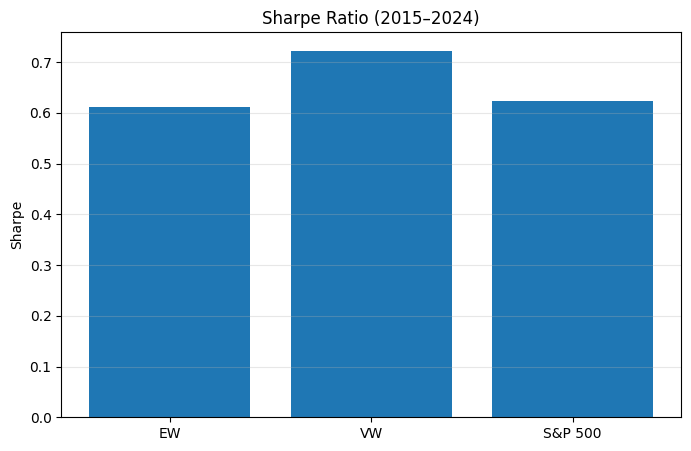

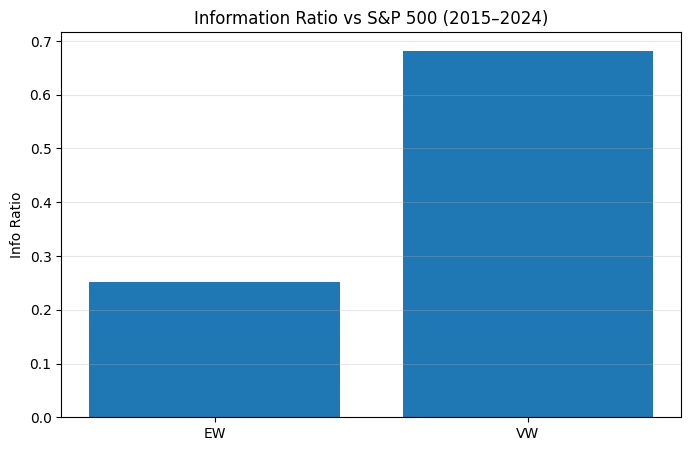

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----- Compute SP500 summary stats (rf = 0) -----
trading_days = 252
spx_ann_ret = np.exp(sp500_log.mean() * trading_days) - 1
spx_ann_vol = sp500_log.std() * np.sqrt(trading_days)
spx_sharpe  = (spx_ann_ret - 0.0) / spx_ann_vol

# ----- Build a summary table -----
summary = pd.DataFrame({
    "Annualized Return": {
        "EW": ew_stats["Annualized Return"],
        "VW": vw_stats["Annualized Return"],
        "S&P 500": spx_ann_ret
    },
    "Annualized Volatility": {
        "EW": ew_stats["Annualized Volatility"],
        "VW": vw_stats["Annualized Volatility"],
        "S&P 500": spx_ann_vol
    },
    "Sharpe Ratio": {
        "EW": ew_stats["Sharpe Ratio"],
        "VW": vw_stats["Sharpe Ratio"],
        "S&P 500": spx_sharpe
    },
    # Info Ratio only makes sense vs. the benchmark; omit for SPX
    "Information Ratio vs SPX": {
        "EW": ew_stats.get("Information Ratio", np.nan),
        "VW": vw_stats.get("Information Ratio", np.nan),
        "S&P 500": np.nan
    }
})

# Nice printout
print("\nPortfolio Performance Summary (2015–2024):")
display(summary.style.format({
    "Annualized Return": "{:.2%}",
    "Annualized Volatility": "{:.2%}",
    "Sharpe Ratio": "{:.2f}",
    "Information Ratio vs SPX": "{:.2f}"
}))

# ----- Plots (one metric per figure; clean & readable) -----

# 1) Annualized Return
plt.figure(figsize=(8,5))
plt.bar(summary.index, summary["Annualized Return"])
plt.title("Annualized Return (2015–2024)")
plt.ylabel("Return")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.grid(axis="y", alpha=0.3)
plt.show()

# 2) Annualized Volatility
plt.figure(figsize=(8,5))
plt.bar(summary.index, summary["Annualized Volatility"])
plt.title("Annualized Volatility (2015–2024)")
plt.ylabel("Volatility")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.grid(axis="y", alpha=0.3)
plt.show()

# 3) Sharpe Ratio
plt.figure(figsize=(8,5))
plt.bar(summary.index, summary["Sharpe Ratio"])
plt.title("Sharpe Ratio (2015–2024)")
plt.ylabel("Sharpe")
plt.grid(axis="y", alpha=0.3)
plt.show()

# 4) Information Ratio (only EW/VW)
plt.figure(figsize=(8,5))
ir_series = summary.loc[["EW", "VW"], "Information Ratio vs SPX"].astype(float)
plt.bar(ir_series.index, ir_series.values)
plt.title("Information Ratio vs S&P 500 (2015–2024)")
plt.ylabel("Info Ratio")
plt.grid(axis="y", alpha=0.3)
plt.show()


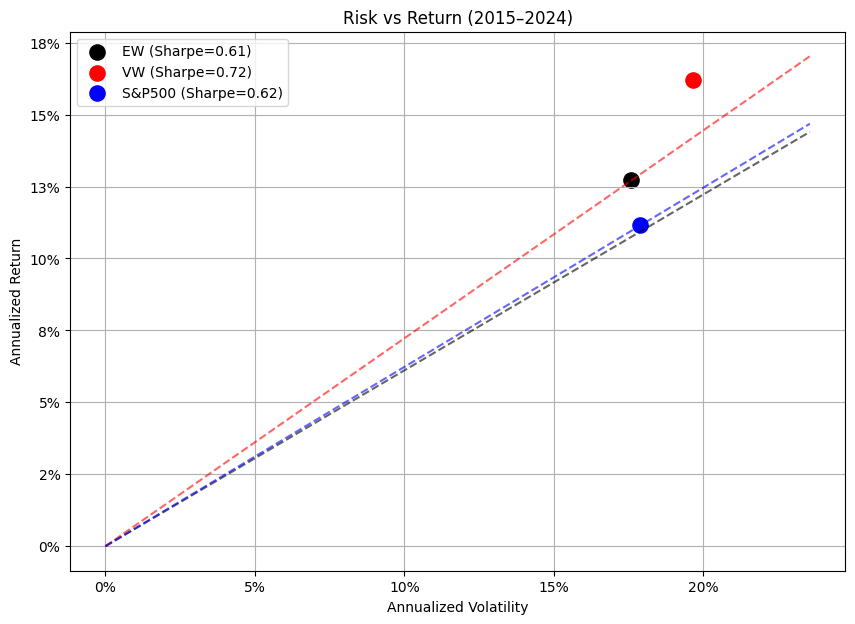

In [16]:
import matplotlib.pyplot as plt

# --- Collect stats ---
ew_ret, ew_vol, ew_sharpe = ew_stats["Annualized Return"], ew_stats["Annualized Volatility"], ew_stats["Sharpe Ratio"]
vw_ret, vw_vol, vw_sharpe = vw_stats["Annualized Return"], vw_stats["Annualized Volatility"], vw_stats["Sharpe Ratio"]

# Benchmark stats (from earlier calc)
spx_ann_ret, spx_ann_vol, spx_sharpe = (
    np.exp(sp500_log.mean() * trading_days) - 1,
    sp500_log.std() * np.sqrt(trading_days),
    (np.exp(sp500_log.mean() * trading_days) - 1) / (sp500_log.std() * np.sqrt(trading_days))
)

# --- Scatter plot ---
plt.figure(figsize=(10,7))

plt.scatter(ew_vol, ew_ret, color="black", s=120, marker="o", label=f"EW (Sharpe={ew_sharpe:.2f})")
plt.scatter(vw_vol, vw_ret, color="red", s=120, marker="o", label=f"VW (Sharpe={vw_sharpe:.2f})")
plt.scatter(spx_ann_vol, spx_ann_ret, color="blue", s=120, marker="o", label=f"S&P500 (Sharpe={spx_sharpe:.2f})")

# Draw Sharpe lines (Capital Market Line style)
max_vol = max(ew_vol, vw_vol, spx_ann_vol) * 1.2
for ret, vol, sharpe, color in [
    (ew_ret, ew_vol, ew_sharpe, "black"),
    (vw_ret, vw_vol, vw_sharpe, "red"),
    (spx_ann_ret, spx_ann_vol, spx_sharpe, "blue")
]:
    x_vals = np.linspace(0, max_vol, 100)
    y_vals = sharpe * x_vals
    plt.plot(x_vals, y_vals, linestyle="--", color=color, alpha=0.6)

# Labels and style
plt.title("Risk vs Return (2015–2024)")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.legend()
plt.grid(True)

# Format as percentages
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.show()


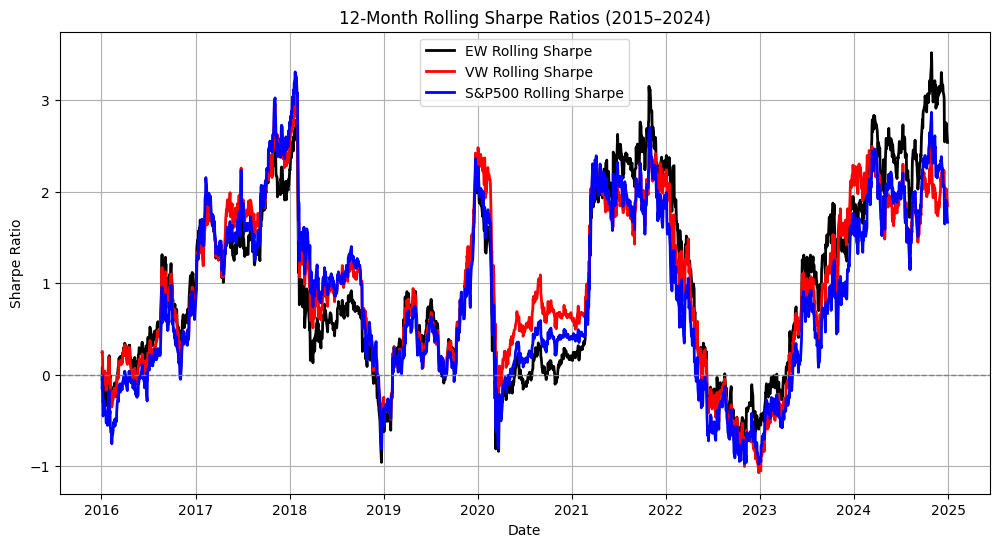

In [17]:
import matplotlib.pyplot as plt

# --- Prepare series ---
ew_log = df_returns["EW_Portfolio_Log"].dropna()
vw_log = df_returns["VW_Portfolio_Log"].dropna()
spx_log = sp500_log.dropna()

# Align all to common dates
common_idx = ew_log.index.intersection(vw_log.index).intersection(spx_log.index)
ew_log, vw_log, spx_log = ew_log.loc[common_idx], vw_log.loc[common_idx], spx_log.loc[common_idx]

# --- Rolling Sharpe function ---
def rolling_sharpe(series, window=252):
    mean = series.rolling(window).mean() * trading_days
    vol = series.rolling(window).std() * np.sqrt(trading_days)
    sharpe = mean / vol
    return sharpe

# --- Compute 12M rolling Sharpe ---
ew_roll_sharpe = rolling_sharpe(ew_log, 252)
vw_roll_sharpe = rolling_sharpe(vw_log, 252)
spx_roll_sharpe = rolling_sharpe(spx_log, 252)

# --- Plot ---
plt.figure(figsize=(12,6))
plt.plot(ew_roll_sharpe.index, ew_roll_sharpe, label="EW Rolling Sharpe", color="black", linewidth=2)
plt.plot(vw_roll_sharpe.index, vw_roll_sharpe, label="VW Rolling Sharpe", color="red", linewidth=2)
plt.plot(spx_roll_sharpe.index, spx_roll_sharpe, label="S&P500 Rolling Sharpe", color="blue", linewidth=2)

plt.title("12-Month Rolling Sharpe Ratios (2015–2024)")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.legend()
plt.grid(True)
plt.show()


# Cumulativa Returns for both Portfolios, S&P500 and risk-free

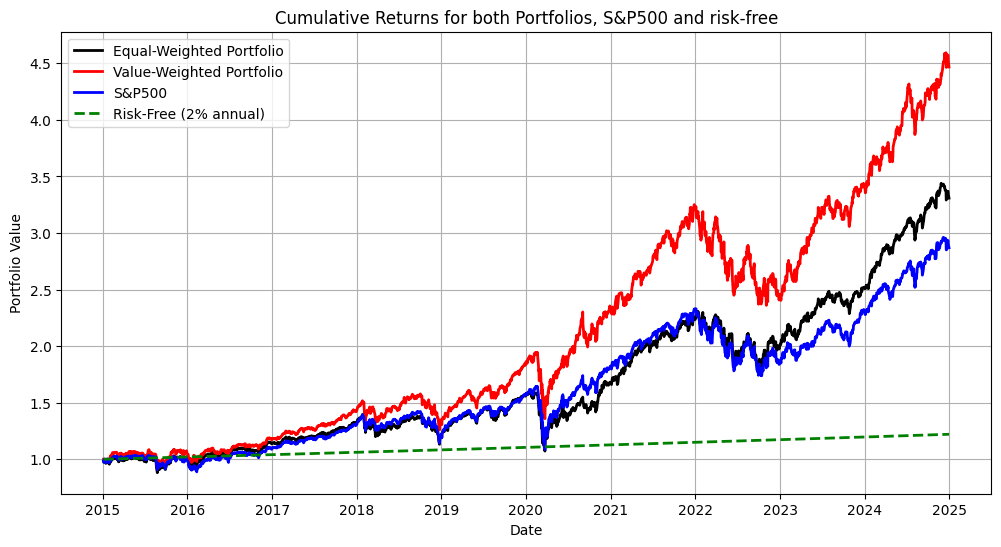

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# --- Prepare log returns (already in df_returns) ---
ew_log = df_returns["EW_Portfolio_Log"].dropna()
vw_log = df_returns["VW_Portfolio_Log"].dropna()
spx_log = sp500_log.dropna()

# Align to common index
common_idx = ew_log.index.intersection(vw_log.index).intersection(spx_log.index)
ew_log, vw_log, spx_log = ew_log.loc[common_idx], vw_log.loc[common_idx], spx_log.loc[common_idx]

# --- Compute cumulative returns (Growth of $1) ---
ew_cum = np.exp(ew_log.cumsum())
vw_cum = np.exp(vw_log.cumsum())
spx_cum = np.exp(spx_log.cumsum())

# Risk-free: assume 2% annualized constant rate
rf_rate = 0.02
rf_daily = rf_rate / 252
rf_cum = np.exp(rf_daily * np.arange(len(common_idx)))
rf_cum = pd.Series(rf_cum, index=common_idx, name="Risk-Free")

# --- Plot cumulative growth ---
plt.figure(figsize=(12,6))
plt.plot(ew_cum.index, ew_cum, label="Equal-Weighted Portfolio", linewidth=2, color="black")
plt.plot(vw_cum.index, vw_cum, label="Value-Weighted Portfolio", linewidth=2, color="red")
plt.plot(spx_cum.index, spx_cum, label="S&P500", linewidth=2, color="blue")
plt.plot(rf_cum.index, rf_cum, label="Risk-Free (2% annual)", linewidth=2, color="green", linestyle="--")

plt.title("Cumulative Returns for both Portfolios, S&P500 and risk-free")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()

# Project 1: Part B

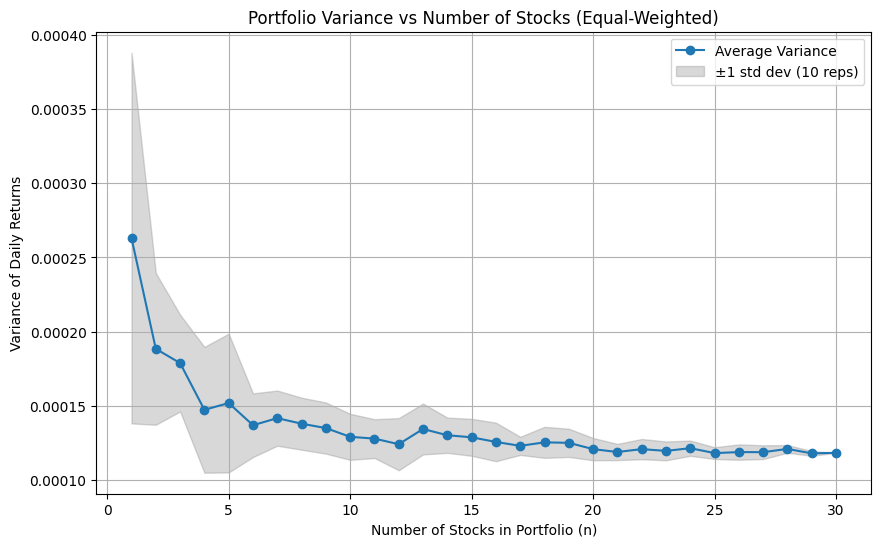

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Data: daily log returns for the 30 selected stocks ---
stock_returns = df_returns[selected].dropna()

# --- Parameters ---
reps = 10
max_n = len(selected)
results = []

# --- Experiment ---
np.random.seed(42)  # reproducibility

for n in range(1, max_n+1):
    variances = []
    for _ in range(reps):
        # (a) choose n stocks
        chosen = np.random.choice(selected, size=n, replace=False)
        
        # (b) equal-weighted portfolio return
        port_rets = stock_returns[chosen].mean(axis=1)
        
        # (c) compute variance of daily return
        var = port_rets.var()
        variances.append(var)
    
    # store average variance for this n
    results.append({
        "n": n,
        "avg_variance": np.mean(variances),
        "std_variance": np.std(variances)  # spread across runs
    })

# --- Convert to DataFrame ---
df_var = pd.DataFrame(results)

# --- Plot: Portfolio variance vs n ---
plt.figure(figsize=(10,6))
plt.plot(df_var["n"], df_var["avg_variance"], marker="o", label="Average Variance")
plt.fill_between(df_var["n"], 
                 df_var["avg_variance"] - df_var["std_variance"],
                 df_var["avg_variance"] + df_var["std_variance"],
                 color="gray", alpha=0.3, label="±1 std dev (10 reps)")
plt.title("Portfolio Variance vs Number of Stocks (Equal-Weighted)")
plt.xlabel("Number of Stocks in Portfolio (n)")
plt.ylabel("Variance of Daily Returns")
plt.legend()
plt.grid(True)
plt.show()
